# icpipe quickstart

Load a SWIFT IC HDF5 file, compute the matter power spectrum and the velocity power spectrum, and overlay against linear theory from CLASS.

Prerequisites:
- `pip install -e .` from the project root (registers the `icpipe` package).
- An IC file in `data/` (one is generated by `./run_pipeline.sh`).
- A CLASS P(k) table at the IC redshift (also produced by the pipeline).

All units are converted to (Mpc/h) and (km/s) consistently.

In [1]:
# If launched from notebooks/, change up to the project root so
# the relative 'data/' paths used below resolve correctly.
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('cwd:', os.getcwd())

cwd: /home/jgkim/Dropbox/Projects/cosmo-pipeline


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from icpipe import ICField, LinearTheory

IC_FILE     = 'data/ics_swift_n256_z200_L512.hdf5'
CLASS_PK_Z0 = 'data/class_pk_z0_pk.dat'    # back-scaled below to match MUSIC2
H0          = 67.11
OMEGA_M     = 0.3

h = H0 / 100.0

## 1. Load the IC and inspect

In [3]:
f = ICField(IC_FILE, h=h)
print(f)
print(f'k_fund    : {f.kfund_mpch:.4g} h/Mpc')
print(f'k_Nyquist : {f.knyq_mpch:.4g} h/Mpc')

<ICField N=16777216 (256^3) L=762.9 Mpc z=200 ngrid=256 interlace=True velocities=yes>
k_fund    : 0.01227 h/Mpc
k_Nyquist : 1.571 h/Mpc


## 2. Compute the density and velocity power spectra

In [4]:
pk = f.power('delta', nkbins=40)
pv = f.power('velocity', nkbins=40)

print('density:', pk)
print('velocity units:', pv.units_P)

density: PowerSpectrumResult(k=array([0.01735501, 0.02125546, 0.02454369, 0.02744068, 0.03005976,
       0.03471002, 0.03778109, 0.04270017, 0.04849462, 0.05431921,
       0.06162313, 0.06925607, 0.07755969, 0.08724706, 0.09817499,
       0.11092764, 0.12499461, 0.14056091, 0.15839871, 0.17834664,
       0.20062263, 0.2258478 , 0.25411893, 0.28603846, 0.32200209,
       0.36255967, 0.40832508, 0.45973028, 0.5176367 , 0.58277793,
       0.65628552, 0.73911566, 0.83222072, 0.9370806 , 1.05512538,
       1.18802947, 1.33771786]), P=array([-6.94247582, -6.98786717, -7.05354076, -7.11430889, -7.17728873,
       -7.28016207, -7.33671283, -7.41592412, -7.48264924, -7.52661298,
       -7.56484657, -7.6038309 , -7.65410786, -7.71711512, -7.77384097,
       -7.81114211, -7.83125751, -7.85795039, -7.89074283, -7.91019941,
       -7.92385182, -7.94129603, -7.95172696, -7.96200522, -7.96973748,
       -7.97622869, -7.98130246, -7.98536056, -7.9886148 , -7.99114284,
       -7.99314288, -7.99469995, 

## 3. Linear-theory predictions from the same CLASS P(k)

In [5]:
# MUSIC2 generates ICs by back-scaling CLASS-z=0 with the no-radiation
# growth factor D+(z) (ZeroRadiation=true). We compare against the same
# convention so the density ratio sits at 1.
th = LinearTheory.from_class_backscaled(
    CLASS_PK_Z0, z_target=f.redshift, h=h, Omega_m=OMEGA_M)
k_grid = np.logspace(-3, np.log10(f.knyq_mpch), 200)
Pk_th  = th.Pk(k_grid)
Pv_th  = th.Pv(k_grid)
print(f'a={th.a:.3e}  H={th.H_kmsMpc:.3g} km/s/Mpc  f={th.f_growth:.4g}  aHf={th.aHf:.3g} km/s/Mpc')

a=4.975e-03  H=1.05e+05 km/s/Mpc  f=1  aHf=521 km/s/Mpc


## 4. Plot density and velocity spectra side-by-side

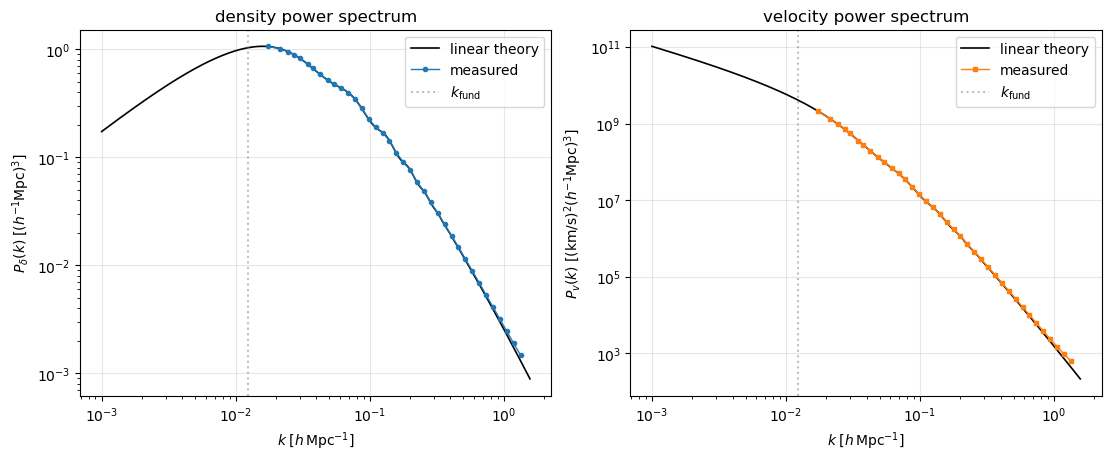

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax[0].loglog(k_grid, Pk_th, 'k-', lw=1.2, label='linear theory')
ax[0].loglog(pk.k, pk.P_raw, 'o-', ms=3, lw=1, label='measured')
ax[0].axvline(f.kfund_mpch, color='gray', ls=':', alpha=0.5, label=r'$k_{\rm fund}$')
ax[0].set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax[0].set_ylabel(r'$P_\delta(k)\;[(h^{-1}\mathrm{Mpc})^3]$')
ax[0].set_title('density power spectrum')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].loglog(k_grid, Pv_th, 'k-', lw=1.2, label='linear theory')
ax[1].loglog(pv.k, pv.P_raw, 's-', ms=3, lw=1, color='C1', label='measured')
ax[1].axvline(f.kfund_mpch, color='gray', ls=':', alpha=0.5, label=r'$k_{\rm fund}$')
ax[1].set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax[1].set_ylabel(r'$P_v(k)\;[(\mathrm{km/s})^2(h^{-1}\mathrm{Mpc})^3]$')
ax[1].set_title('velocity power spectrum')
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.show()

## 5. The take-home: ratio to theory

The velocity ratio sits noticeably below 1 across the resolved-k range, while the density ratio is close to 1. This is the box-size sensitivity of velocity statistics — see `notebooks/02_box_size_sensitivity.ipynb` for a quantitative treatment with multiple box sizes.

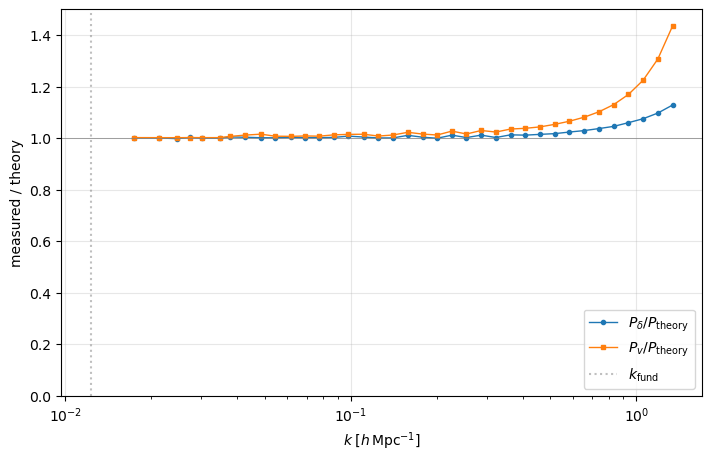

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.semilogx(pk.k, pk.P_raw / th.Pk(pk.k), 'o-', ms=3, lw=1, label=r'$P_\delta/P_{\rm theory}$')
ax.semilogx(pv.k, pv.P_raw / th.Pv(pv.k), 's-', ms=3, lw=1, label=r'$P_v/P_{\rm theory}$')
ax.axhline(1, color='gray', lw=0.5)
ax.axvline(f.kfund_mpch, color='gray', ls=':', alpha=0.5, label=r'$k_{\rm fund}$')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'measured / theory')
ax.set_ylim(0, 1.5)
ax.legend(); ax.grid(alpha=0.3)
plt.show()